In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle

print("TensorFlow Version:", tf.__version__)
print(" Libraries ready!")

TensorFlow Version: 2.21.0
✅ Libraries ready!


In [20]:
 
df = pd.read_csv('../data/processed/breast_cancer_cleaned.csv')
 

In [22]:
df.drop(columns=['Unnamed: 0'] ,inplace=True)

In [23]:


 
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [24]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


TRAIN TEST SPLIT 


In [ ]:
X_train , X_test , y_train , y_test = train_test_split( X, y,test_size=0.2,random_state=42)

with open('../models/scaler.pkl' ,'rb') as f:
    scaler = pickle.load(f)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


print("Data ready!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

✅ Data ready!
X_train shape: (455, 30)
X_test shape: (114, 30)


CREATE MODEL

In [26]:
# model 

model = Sequential(
    [
        Dense(64 ,activation='relu' , input_shape = (30 ,)),
        Dense(32 ,activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

model.summary()

c:\Users\ABHISHEK KUMAR SINGH\Desktop\breast_cancer_dl\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',        # Learning algorithm
    loss='binary_crossentropy', # Loss function
    metrics=['accuracy']     # Track karne ke liye
)

print(" Model compiled!")

✅ Model compiled!


In [28]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)


In [29]:
history = model.fit(
    X_train, y_train,
    epochs=50,           # 50 baar data dekhe
    batch_size=32,       # Ek baar mein 32 samples
    validation_split=0.2, # 20% validation ke liye
    verbose=1            # Progress dikhao
)

print("✅ Model trained!")

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5632 - loss: 0.6141 - val_accuracy: 0.8352 - val_loss: 0.4670
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9148 - loss: 0.3785 - val_accuracy: 0.9560 - val_loss: 0.3035
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9423 - loss: 0.2491 - val_accuracy: 0.9670 - val_loss: 0.2086
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9588 - loss: 0.1728 - val_accuracy: 0.9670 - val_loss: 0.1554
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9725 - loss: 0.1294 - val_accuracy: 0.9670 - val_loss: 0.1296
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9780 - loss: 0.1046 - val_accuracy: 0.9780 - val_loss: 0.1142
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9835 - loss: 0.0873 - val_accuracy: 0.9780 - val_loss: 0.1058
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9808 - loss: 0.0761 - val_accuracy: 0.9780 - v

MODEL VISULIZATION

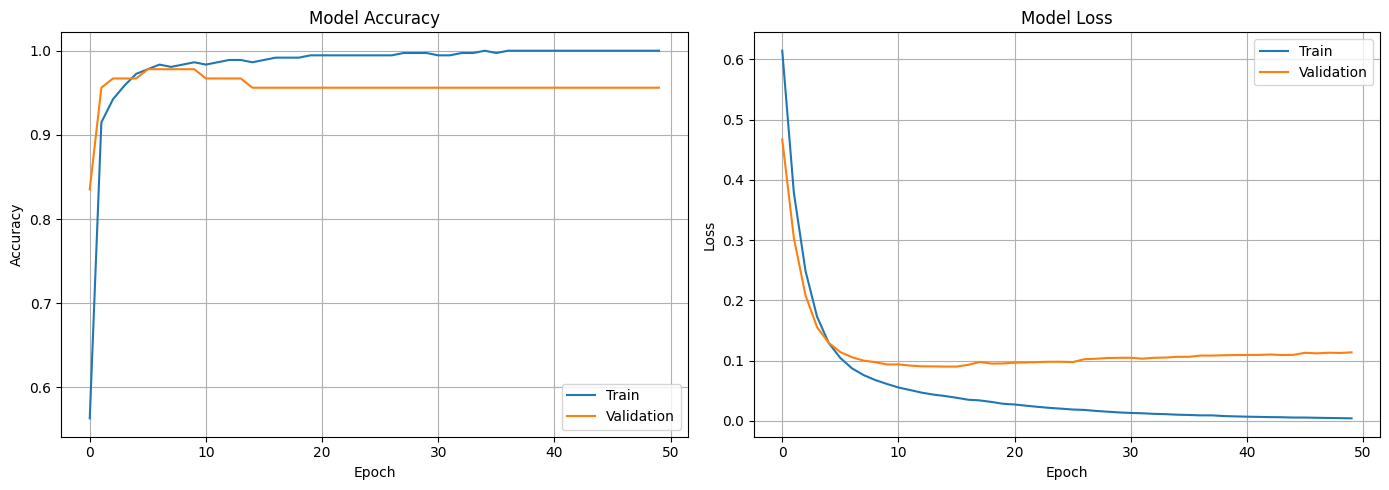

In [30]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss Plot
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../data/processed/training_history.png', dpi=150)
plt.show()

PREDICATION ON TEST DATA


In [ ]:
 
y_pred_prob = model.predict(X_test)
 
y_pred = (y_pred_prob > 0.5).astype(int)

print("Predictions done!")
print("Sample predictions:", y_pred[:5].flatten())
print("Actual values:     ", y_test[:5].values)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predictions done!
Sample predictions: [0 1 1 0 0]
Actual values:      [0 1 1 0 0]


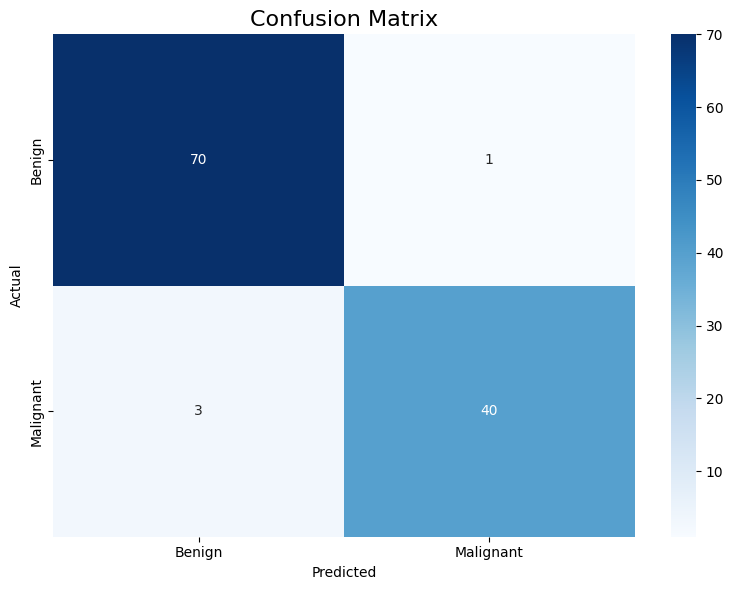

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150)
plt.show()

In [33]:
from sklearn.metrics import classification_report

print("📊 Classification Report:")
print(classification_report(
    y_test, 
    y_pred,
    target_names=['Benign', 'Malignant']
))

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Improved Model
model_v2 = Sequential([
    # Hidden Layer 1
    Dense(64, activation='relu', input_shape=(30,)),
    Dropout(0.3),  # 30% neurons randomly off

    # Hidden Layer 2
    Dense(32, activation='relu'),
    Dropout(0.2),  # 20% neurons randomly off

    # Output Layer
    Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

c:\Users\ABHISHEK KUMAR SINGH\Desktop\breast_cancer_dl\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # Val loss dekho
    patience=10,          # 10 epochs tak wait karo
    restore_best_weights=True  # Best model rakho
)

# Class Weights
class_weights = {
    0: 1.0,   # Benign - normal weight
    1: 2.0    # Malignant - double weight!
}

# Train karo
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

print("Improved model trained!")


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7198 - loss: 0.7531 - val_accuracy: 0.9011 - val_loss: 0.4664
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8599 - loss: 0.5467 - val_accuracy: 0.9451 - val_loss: 0.3403
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9121 - loss: 0.4195 - val_accuracy: 0.9560 - val_loss: 0.2539
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9258 - loss: 0.3288 - val_accuracy: 0.9560 - val_loss: 0.1972
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9615 - loss: 0.2371 - val_accuracy: 0.9560 - val_loss: 0.1605
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.2248 - val_accuracy: 0.9780 - val_loss: 0.1413
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9505 - loss: 0.1700 - val_accuracy: 0.9780 - val_loss: 0.1277
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.1474 - val_accuracy: 0.9670 - 

In [36]:
# Predictions
y_pred_v2_prob = model_v2.predict(X_test)
y_pred_v2 = (y_pred_v2_prob > 0.5).astype(int)

# Classification Report
from sklearn.metrics import classification_report
print("📊 Improved Model Report:")
print(classification_report(
    y_test,
    y_pred_v2,
    target_names=['Benign', 'Malignant']
))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
📊 Improved Model Report:
              precision    recall  f1-score   support

      Benign       0.99      0.96      0.97        71
   Malignant       0.93      0.98      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [37]:
import os

# models folder already hai
os.makedirs('../models', exist_ok=True)

# Model save karo
model_v2.save('../models/breast_cancer_model.h5')

print("✅ Model saved!")

✅ Model saved!


In [38]:
from tensorflow.keras.models import load_model

# Model load karo
loaded_model = load_model('../models/breast_cancer_model.h5')

print("✅ Model loaded!")
loaded_model.summary()

✅ Model loaded!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,099 (16.02 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [39]:
# Loaded model se prediction karo
test_pred = loaded_model.predict(X_test)
test_pred = (test_pred > 0.5).astype(int)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, test_pred)

print(f"✅ Loaded Model Accuracy: {accuracy*100:.2f}%")

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000018388E8E200> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
✅ Loaded Model Accuracy: 96.49%
